In [1]:
"""
Project mortality effects for forecast ensemble and baseline period
"""

import datetime
import os
import uuid

from dotenv import load_dotenv
import isku
import numpy as np
import xarray as xr

from poreallas.extract import make_climtas, make_tas_monthly_histogram
from poreallas.project import mortality_effect_model, calculate_beta

In [10]:
load_dotenv()
DATA_DIR = "/home/emily_zuetell/projects/poreallas/data/"

# Input
TAS_FORECAST_URI = (
    "/home/emily_zuetell/projects/poreallas/data/2608_forecast_adj_corrected.zarr"
)
# ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
ERA5_URI = "/home/emily_zuetell/projects/poreallas/data/era5_adj_corrected.zarr"
GAMMA_URI = "/home/emily_zuetell/projects/poreallas/data/gammas_local.zarr"
SOCIOECONOMICS_URI = (
    "/home/emily_zuetell/projects/poreallas/data/socioeconomics_local.zarr"
)
REGIONS_URI = "/home/emily_zuetell/projects/poreallas/data/impact_region.parquet"

# Output
EFFECTS_URI = os.getenv("POREALLAS_EFFECTS_URI")

In [17]:
def is_gcs_uri(s: str) -> bool:
    """Check if a string is a Google Cloud Storage URI"""
    return s.strip().startswith(("gs://", "gcs://"))


def read_reanalysis(uri: str) -> xr.Dataset:
    # _ds = xr.load_dataset(uri, engine = 'zarr', chunks = {}, backend_kwargs = {"storage_options": {"token": "anon"}})
    _ds = xr.load_dataset(uri)
    # Clean up longitude. The data goes from longitude 0 to 360. It needs to go -180 to 180 in ascending order.
    _ds["longitude"] = (_ds["longitude"] + 180) % 360 - 180
    _ds = _ds.sortby("longitude")
    _ds = _ds.rename({"longitude": "lon", "latitude": "lat"})
    _ds = _ds.chunk("auto")

    return _ds


def read_forecast_ensemble(uri: str) -> xr.Dataset:
    if is_gcs_uri(uri):
        b_kw = {"storage_options": {"token": "anon"}}
    else:
        b_kw = {}

    _ds = xr.load_dataset(
        uri,
        engine="zarr",
        chunks={},
        backend_kwargs=b_kw,
    )
    _ds = _ds.sortby("time")
    # Clean up longitude. The data goes from longitude 0 to 360. It needs to go -180 to 180 in ascending order.
    _ds["longitude"] = (_ds["longitude"] + 180) % 360 - 180
    _ds = _ds.sortby("longitude")
    _ds = _ds.rename({"latitude": "lat", "longitude": "lon"})
    _ds = _ds.chunk("auto")

    # TODO: We prob don't want this here. Should be in earlier cleaning. Here for backwards compatibility.
    # Drop months without required number of obs. Forecast ensemble is for a fixed number of days so we expect to usually trim off the last month of the forecast if it is ragged and missing days beyond a threshold.
    _dt_dim = "time"
    _n_initial = _ds[_dt_dim].size
    _number_obs = _ds[_dt_dim].resample(time="ME").count()
    _days_in_month = _number_obs[_dt_dim].dt.days_in_month
    required_percent = 0.9
    _min_req = np.round(_days_in_month * required_percent)
    _qualifying_months = _number_obs.where(_number_obs >= _min_req, drop=True)[
        "time"
    ].dt.month
    _ds = _ds.where(_ds[_dt_dim].dt.month.isin(_qualifying_months), drop=True)

    _n_current = _ds[_dt_dim].size
    _n_initial_months = _number_obs[_dt_dim].size
    _n_qualifying_months = _qualifying_months["time"].size

    print(
        f"continuing with {_n_qualifying_months} of {_n_initial_months} forecast months after removing incomplete months"
    )
    print(
        f"continuing with {_n_current} of {_n_initial} forecast periods after removing incomplete months"
    )

    assert (_n_qualifying_months - _n_initial_months) < 2, (
        "More than one incomplete month was removed from the forecast while checking for incomplete months. Something unexpected is happening."
    )

    return _ds


def read_regions(uri: str) -> isku.GridWeightingRegions:
    _region_weights = xr.load_dataset(uri)[
        ["lat", "lon", "region", "weight"]
    ]  # Load only what we need.
    # Apparently in this version of xarray the `.load()` method type-hints it'll return a DataArray instead of a Dataset.
    # It is a Dataset (I checked). So telling ty to ignore it.
    # # TODO: send bug upstream?
    regions = isku.GridWeightingRegions(_region_weights)  # ty: ignore[invalid-argument-type]
    return regions


def read_gammas(uri: str) -> xr.Dataset:
    return xr.load_dataset(uri)


def read_socioeconomics(uri: str) -> xr.Dataset:
    return xr.load_dataset(uri)

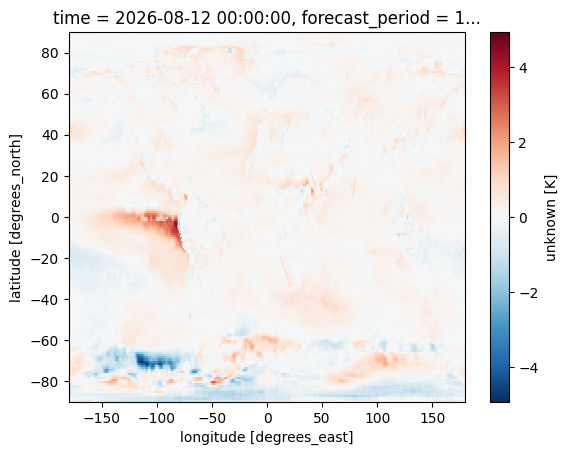

In [28]:
(forecast_ensemble - forecast_ensemble_bm)["tas"].mean(dim="number").isel(
    time=10
).plot()

In [33]:
forecast_ensemble["tas"].attrs

{'GRIB_dataType': 'fc',
 'GRIB_numberOfPoints': 64800,
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': 1,
 'GRIB_stepType': 'instant',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': 0,
 'GRIB_NV': 0,
 'GRIB_Nx': 360,
 'GRIB_Ny': 180,
 'GRIB_cfName': 'unknown',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': 1.0,
 'GRIB_iScansNegatively': 0,
 'GRIB_jDirectionIncrementInDegrees': 1.0,
 'GRIB_jPointsAreConsecutive': 0,
 'GRIB_jScansPositively': 0,
 'GRIB_latitudeOfFirstGridPointInDegrees': 89.5,
 'GRIB_latitudeOfLastGridPointInDegrees': -89.5,
 'GRIB_longitudeOfFirstGridPointInDegrees': 0.5,
 'GRIB_longitudeOfLastGridPointInDegrees': 359.5,
 'GRIB_missingValue': 3.4028234663852886e+38,
 'GRIB_system': 51,
 'GRIB_totalNumber': 0,
 'GRIB_units': 'K',
 'units': 'K',
 'standard_name': 'unknown',
 'GRIB_surface': 0.0,
 'poreallas_created_at': '2026-08-07T21:35:35.674808+00:00',
 'poreallas_uid': '06958675-cb5d-4d90-9812-63c8dd99

In [32]:
forecast_ensemble_bm["tas"].attrs

{'GRIB_dataType': 'fc',
 'GRIB_numberOfPoints': 64800,
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': 1,
 'GRIB_stepType': 'instant',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': 0,
 'GRIB_NV': 0,
 'GRIB_Nx': 360,
 'GRIB_Ny': 180,
 'GRIB_cfName': 'unknown',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': 1.0,
 'GRIB_iScansNegatively': 0,
 'GRIB_jDirectionIncrementInDegrees': 1.0,
 'GRIB_jPointsAreConsecutive': 0,
 'GRIB_jScansPositively': 0,
 'GRIB_latitudeOfFirstGridPointInDegrees': 89.5,
 'GRIB_latitudeOfLastGridPointInDegrees': -89.5,
 'GRIB_longitudeOfFirstGridPointInDegrees': 0.5,
 'GRIB_longitudeOfLastGridPointInDegrees': 359.5,
 'GRIB_missingValue': 3.4028234663852886e+38,
 'GRIB_system': 51,
 'GRIB_totalNumber': 0,
 'GRIB_units': 'K',
 'units': 'K',
 'standard_name': 'unknown',
 'GRIB_surface': 0.0,
 'poreallas_created_at': '2026-08-26T04:08:04.804007+00:00',
 'poreallas_uid': '078e9723-816c-49bb-9154-507e78a8

In [18]:
# Read Data
reanalysis = read_reanalysis(ERA5_URI)
forecast_ensemble = read_forecast_ensemble(TAS_FORECAST_URI)
forecast_ensemble_bm = read_forecast_ensemble(
    "gs://poreallas-public-20260605/v20260825/parsed/forecast_adj-q100.zarr"
)
# regions = read_regions(REGIONS_URI)
# socioeconomics = read_socioeconomics(SOCIOECONOMICS_URI)
# gammas = read_gammas(GAMMA_URI)

continuing with 6 of 6 forecast months after removing incomplete months
continuing with 183 of 183 forecast periods after removing incomplete months
continuing with 7 of 8 forecast months after removing incomplete months
continuing with 211 of 215 forecast periods after removing incomplete months


In [5]:
# Transform gridded data, extracting regional data needed for projections.
histogram_hist_tas = isku.extract_regions(
    reanalysis,
    template=make_tas_monthly_histogram,
    regions=regions,
)
histogram_forecast_tas = isku.extract_regions(
    forecast_ensemble,
    template=make_tas_monthly_histogram,
    regions=regions,
)

In [6]:
# Using the same static beta for forecast and reanalysis projection requires the histogram tas_bin for these data need to be equal, too. So we're  calculating it here.
xr.testing.assert_allclose(
    histogram_hist_tas["tas_bin"],
    histogram_forecast_tas["tas_bin"],
)

climtas = isku.extract_regions(
    reanalysis,
    template=make_climtas,
    regions=regions,
).sel(year=2025, drop=True)
loggdppc = np.log(socioeconomics["gdppc"].sel(year=2023, drop=True))

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


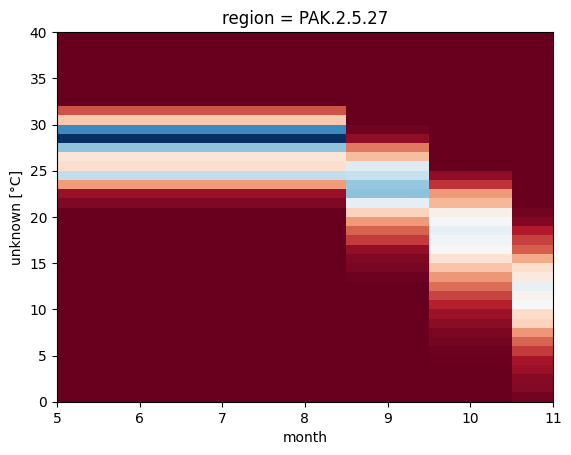

In [24]:
hist_tas = (
    histogram_forecast_tas["histogram_tas"]
    .sel(region="PAK.2.5.27")
    .sum("number")
    .groupby("time.month")
    .sum("time")
)
hist_tas.plot(
    x="month", y="tas_bin", cmap="RdBu", xlim=(5, 11), ylim=(0, 40), add_colorbar=False
)

In [8]:
gammas.covarname

<xarray.DataArray 'covarname' (covarname: 3)> Size: 48B
array(['1', 'climtas', 'loggdppc'], dtype=StringDType())
Coordinates:
  * covarname  (covarname) StringDType() 48B '1' 'climtas' 'loggdppc'

In [7]:
# Calculate a fixed response function, i.e. beta.
# Single, static response function with no adaptation is used for both projections.
# Stick everything together and make sure it aligns and matches. Rechunk all together. Also drop any regions with NaNs.
beta_input = (
    xr.Dataset(
        {
            "tas_bin": histogram_forecast_tas["tas_bin"],
            "climtas": climtas["climtas"],
            "loggdppc": loggdppc,
            "gamma": gammas["gamma_sampled"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "tas_bin": -1,  # This also needs to be all in memory.
            "age_cohort": 1,  # We're doing all age_cohorts at once but could be done one-by-one.
            "degree": -1,  # For gammas and polynomial calculations. Should all be in memory.
        },
    )
    .unify_chunks()
)
fixed_beta = calculate_beta(beta_input).astype("float32").compute()
fixed_beta["beta"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Temperature mortality rate",
}
# Do beta allowing only hot deaths by 0-ing out everthing on the cold side of the minimum-mortality temperature.
fixed_beta["beta_hotonly"] = fixed_beta["beta"].where(
    fixed_beta["tas_bin"] > fixed_beta["mmt"], other=0
)
fixed_beta["beta_hotonly"].attrs["long_name"] = "Hot temperature mortality rate"

# Do beta, allowing only COLD deaths by 0-ing out everything on the warm side of the minimum-mortality temperature.
fixed_beta["beta_coldonly"] = fixed_beta["beta"].where(
    fixed_beta["tas_bin"] < fixed_beta["mmt"], other=0
)
fixed_beta["beta_coldonly"].attrs["long_name"] = "Cold temperature mortality rate"

In [ ]:
fixed_beta.to_zarr("2608_beta_qdm_gamma_sampled.zarr")

In [9]:
# Project mortality.
# Start with forecast ensemble.
forecast_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_forecast_tas["histogram_tas"],
            "beta": fixed_beta["beta"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
            "number": 1,
        },
    )
    .unify_chunks()
)
projected_forecast = isku.project(
    forecast_input, model=mortality_effect_model
).compute()
projected_forecast["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Temperature mortality",
}

In [10]:
# Now hot-only projection
forecast_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_forecast_tas["histogram_tas"],
            "beta": fixed_beta["beta_hotonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
            "number": 1,
        },
    )
    .unify_chunks()
)
projected_forecast_hotonly = isku.project(
    forecast_input, model=mortality_effect_model
).compute()
projected_forecast_hotonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Hot temperature mortality",
}

In [12]:
# Now cold-only projection
forecast_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_forecast_tas["histogram_tas"],
            "beta": fixed_beta["beta_coldonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
            "number": 1,
        },
    )
    .unify_chunks()
)
projected_forecast_coldonly = isku.project(
    forecast_input, model=mortality_effect_model
).compute()
projected_forecast_coldonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Cold temperature mortality",
}

In [13]:
# Now do the baseline period.
# Stick everything together and make sure it aligns and matches. Rechunk all together. Also drop any regions with NaNs.
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist = isku.project(hist_input, model=mortality_effect_model).compute()
projected_hist["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Temperature mortality",
}

In [14]:
# Now hot-only projection
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta_hotonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist_hotonly = isku.project(
    hist_input, model=mortality_effect_model
).compute()
projected_hist_hotonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Hot temperature mortality",
}

In [15]:
# Now cold-only projection
hist_input = (
    xr.Dataset(
        {
            "histogram_tas": histogram_hist_tas["histogram_tas"],
            "beta": fixed_beta["beta_coldonly"],
        }
    )
    .dropna(dim="region")
    .chunk(
        {
            "region": "auto",  # "auto" is a sensible default.
            "time": -1,
            "tas_bin": -1,
            "age_cohort": 1,
        },
    )
    .unify_chunks()
)
projected_hist_coldonly = isku.project(
    hist_input, model=mortality_effect_model
).compute()
projected_hist_coldonly["effect"].attrs = {
    "units": "deaths per 100,000 people",
    "long_name": "Cold temperature mortality",
}

In [16]:
# Collect everything and write to storage.
_out = {
    "forecast": projected_forecast,
    "baseline": projected_hist,
    "forecast_hotonly": projected_forecast_hotonly,
    "baseline_hotonly": projected_hist_hotonly,
    "forecast_coldonly": projected_forecast_coldonly,
    "baseline_coldonly": projected_hist_coldonly,
}
_out_dt = xr.DataTree.from_dict(_out)

# Add metadata
_uid = str(uuid.uuid4())
_datetime_now = datetime.datetime.now(datetime.timezone.utc).isoformat()

_out_dt.attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Projected temperature mortality effects",
}

_out_dt["forecast"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["forecast_hotonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected hot temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline_hotonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected hot temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["forecast_coldonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Forecast ensemble projected cold temperature mortality effects",
    "poreallas_temperature_uri": TAS_FORECAST_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}

_out_dt["baseline_coldonly"].attrs |= {
    "poreallas_created_at": _datetime_now,
    "poreallas_uid": _uid,
    "poreallas_description": "Baseline projected cold temperature mortality effects",
    "poreallas_temperature_uri": ERA5_URI,
    "poreallas_socioeconomics_uri": SOCIOECONOMICS_URI,
    "poreallas_model_parameters_uri": GAMMA_URI,
    "poreallas_regions_uri": REGIONS_URI,
}


_out_dt.to_zarr(
    "/home/emily_zuetell/projects/poreallas/data/2608_effect_gamma_sampled.zarr",
    consolidated=True,
)
print("Effects written to ")

Effects written to 


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 0, 'Effect [deaths/100k]')

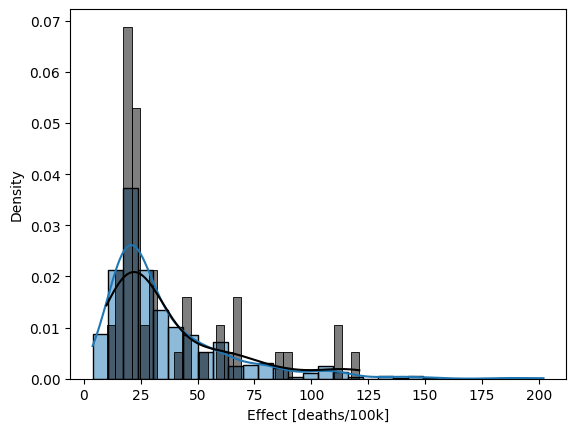

In [36]:
fig, ax = plt.subplots()
mean = projected_forecast["effect"].sel(
    region="CHN.11.109.767", time="2026-07-01", age_cohort="age65plus", sample=1
)
sampled = projected_forecast["effect"].sel(
    region="CHN.11.109.767", time="2026-07-01", age_cohort="age65plus"
)

sns.histplot(sampled.values.flatten(), kde=True, bins=30, ax=ax, stat="density")
sns.histplot(mean.values.flatten(), kde=True, bins=30, ax=ax, stat="density", color="k")
ax.set_xlabel("Effect [deaths/100k]")